In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
university_rate = pd.read_csv("university_datasets.csv", encoding='latin-1')
alumni_first = pd.read_csv("job_placement.csv", encoding='utf-8')
alumni_second = pd.read_csv("global_graduate_employability_index.csv", encoding='latin-1')

In [3]:
university_rate.head()

,World Rank,Institution,Location,National Rank,Quality of Education,Alumni Employment,Quality of Faculty,Research Output,Quality Publications,Influence,Citations,Score
0,1,Harvard University,USA,1,2,1,1,1,1,1,1,100.0
1,2,Stanford University,USA,2,10,3,2,10,4,3,2,96.7
2,3,Massachusetts Institute of Technology,USA,3,3,11,3,30,15,2,6,95.1
3,4,University of Cambridge,United Kingdom,1,5,19,6,12,8,6,19,94.0
4,5,University of Oxford,United Kingdom,2,9,25,10,9,5,7,4,93.2


In [4]:
alumni_first.head()

,id,name,gender,age,degree,stream,college_name,placement_status,salary,gpa,years_of_experience
0,1,John Doe,Male,25,Bachelor's,Computer Science,Harvard University,Placed,60000,3.7,2.0
1,2,Jane Smith,Female,24,Bachelor's,Electrical Engineering,Massachusetts Institute of Technology,Placed,65000,3.6,1.0
2,3,Michael Johnson,Male,26,Bachelor's,Mechanical Engineering,Stanford University,Placed,58000,3.8,3.0
3,4,Emily Davis,Female,23,Bachelor's,Information Technology,Yale University,Not Placed,0,3.5,2.0
4,5,David Brown,Male,24,Bachelor's,Computer Science,Princeton University,Placed,62000,3.9,2.0


In [5]:
alumni_second[alumni_second['University_Name'] == 'Harvard']


,Country,Region,University_Name,Degree_Level,Field_of_Study,Graduation_Year,Employment_Rate_6_Months (%),Employment_Rate_12_Months (%),Average_Starting_Salary_USD,Top_Industry,Job_Role,Skill_1,Skill_2,Skill_3,Skill_Demand_Score (1â100),Remote_Work_Availability (%),Employer_Reputation_Score (1â100),Year
0,USA,North America,Harvard,Bachelor,Engineering,2017,79.3,85.6,66700,Manufacturing/Construction,Robotics Engineer,AutoCAD,Lean Six Sigma,MATLAB,69,8.8,66,2017
52,USA,North America,Harvard,Bachelor,Natural Sciences,2018,84.1,91.7,61200,Research/Academia,Chemist,Statistical Analysis,Laboratory Skills,Scientific Writing,56,13.4,65,2018
88,USA,North America,Harvard,PhD,Healthcare & Medicine,2025,88.5,94.8,149100,Healthcare,Biomedical Researcher,Patient Care,Diagnostics,Clinical Research,53,89.3,51,2025
97,USA,North America,Harvard,PhD,Engineering,2019,94.4,99.7,112100,Manufacturing/Construction,Mechanical Engineer,SolidWorks,Lean Six Sigma,AutoCAD,60,7.7,57,2019
163,USA,North America,Harvard,Master,Social Sciences,2025,85.1,91.6,70600,Government/NGO,Sociologist,Data Analysis,Public Policy,Communication,74,80.3,69,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3358,USA,North America,Harvard,PhD,Computer Science,2016,82.6,86.7,108900,Technology,Cybersecurity Analyst,React,Cloud Computing,Java,54,16.8,58,2016
3400,USA,North America,Harvard,PhD,Natural Sciences,2020,84.0,93.0,94200,Research/Academia,Chemist,Experimental Design,Statistical Analysis,Laboratory Skills,54,29.6,52,2020
3413,USA,North America,Harvard,Bachelor,Social Sciences,2020,74.3,77.3,44100,Government/NGO,Economist,Public Policy,Qualitative Research,Data Analysis,51,35.8,84,2020
3424,USA,North America,Harvard,Bachelor,Data Science & AI,2016,91.3,96.8,78100,Technology/Consulting,Machine Learning Engineer,Deep Learning,Machine Learning,Big Data,72,9.3,56,2016


In [6]:
alumni_second.University_Name.value_counts()

University_Name
UNAM                                 244
University of Buenos Aires           222
University of SÃ£o Paulo             213
King Abdulaziz University            185
Khalifa University                   173
University of Cape Town              163
McGill University                    136
UBC                                  123
University of Toronto                122
Technion                              98
Hebrew University of Jerusalem        95
Stanford                              85
EPFL                                  80
MIT                                   72
UC Berkeley                           70
University of Tokyo                   67
Harvard                               64
Georgia Tech                          63
PSL University                        62
Seoul National University             61
KTH Royal Institute of Technology     59
Ecole Polytechnique                   58
Kyoto University                      56
University of Amsterdam               55


In [7]:
alumni_first.college_name.value_counts()

college_name
University of California--Berkeley           43
University of Michigan--Ann Arbor            43
University of Virginia                       43
University of Illinois--Urbana-Champaign     43
University of Colorado--Boulder              43
University of North Carolina--Chapel Hill    42
University of Maryland--College Park         42
University of California--Santa Cruz         42
University of Pennsylvania                   40
University of Washington                     40
University of Rochester                      34
University of California--Riverside          34
University of Delaware                       34
University of California--San Francisco      34
University of Texas--Dallas                  34
University of Connecticut                    33
University of California--Los Angeles        23
University of Texas--Austin                  18
University of California--San Diego          10
Harvard University                            1
Massachusetts Institute of 

In [8]:
university_full_names = {
    'Harvard': 'Harvard University',
    'MIT': 'Massachusetts Institute of Technology',
    'Technion': 'Technion – Israel Institute of Technology',
    'IIT Bombay': 'Indian Institute of Technology Bombay',
    'University of Cape Town': 'University of Cape Town',
    'LSE': 'London School of Economics and Political Science',
    'Karolinska Institute': 'Karolinska Institute',
    'University of Amsterdam': 'University of Amsterdam',
    'Imperial College London': 'Imperial College London',
    'UNAM': 'National Autonomous University of Mexico',
    'Hebrew University of Jerusalem': 'Hebrew University of Jerusalem',
    'KTH Royal Institute of Technology': 'Royal Institute of Technology',
    'Seoul National University': 'Seoul National University',
    'NUS': 'National University of Singapore',
    'University of São Paulo': 'University of São Paulo',
    'University of Toronto': 'University of Toronto',
    'ANU': 'Australian National University',
    'University of Buenos Aires': 'University of Buenos Aires',
    'King Abdulaziz University': 'King Abdulaziz University',
    'Fudan University': 'Fudan University',
    'Stanford': 'Stanford University',
    'McGill University': 'McGill University',
    'UBC': 'University of British Columbia',
    'PSL University': 'Paris Sciences et Lettres University',
    'Khalifa University': 'Khalifa University',
    'Ecole Polytechnique': 'École Polytechnique',
    'UC Berkeley': 'University of California, Berkeley',
    'University of Melbourne': 'University of Melbourne',
    'University of Sydney': 'University of Sydney',
    'EPFL': 'École Polytechnique Fédérale de Lausanne',
    'ETH Zurich': 'Swiss Federal Institute of Technology Zurich',
    'TU Munich': 'Technical University of Munich',
    'TU Delft': 'Delft University of Technology',
    'Heidelberg University': 'Heidelberg University',
    'University of Tokyo': 'University of Tokyo',
    'Kyoto University': 'Kyoto University',
    'KAIST': 'Korea Advanced Institute of Science and Technology',
    'IIT Delhi': 'Indian Institute of Technology Delhi',
    'IISc Bangalore': 'Indian Institute of Science Bangalore',
    'University of Washington': 'University of Washington - Seattle',
    'Georgia Tech': 'Georgia Institute of Technology',
    'Peking University': 'Peking University',
    'Tsinghua University': 'Tsinghua University',
    'NTU': 'Nanyang Technological University',
    'University of Oxford': 'University of Oxford',
    'University of Cambridge': 'University of Cambridge',
    'University of Chicago': 'University of Chicago',
    'Yale University': 'Yale University',
    'Columbia University': 'Columbia University',
    'Princeton University': 'Princeton University',
    'Caltech': 'California Institute of Technology',
    'Johns Hopkins University': 'Johns Hopkins University',
    'University of Pennsylvania': 'University of Pennsylvania',
    'Cornell University': 'Cornell University',
    'UCLA': 'University of California, Los Angeles',
    'University of Michigan': 'University of Michigan, Ann Arbor',
    'UCSD': 'University of California, San Diego',
    'Northwestern University': 'Northwestern University',
    'Duke University': 'Duke University',
    'NYU': 'New York University',
    'University of Wisconsin': 'University of Wisconsin–Madison',
    'Sorbonne University': 'Sorbonne University',
    'University of Texas at Austin': 'University of Texas at Austin',
    'UIUC': 'University of Illinois at Urbana–Champaign',
    'UNC Chapel Hill': 'University of North Carolina at Chapel Hill',
    'University of Edinburgh': 'University of Edinburgh',
    'University of Minnesota': 'University of Minnesota Twin Cities',
    'WUSTL': 'Washington University in St. Louis',
    'University of Copenhagen': 'University of Copenhagen',
    'Ohio State University': 'Ohio State University',
    'Rutgers University': 'Rutgers University-New Brunswick',
    'UCDavis': 'University of California, Davis',
    'Penn State': 'Pennsylvania State University',
    'University of Manchester': 'University of Manchester',
    'Weizmann Institute': 'Weizmann Institute of Science',
    'LMU Munich': 'Ludwig Maximilian University of Munich',
    'University of Colorado Boulder': 'University of Colorado Boulder',
    'USC': 'University of Southern California',
    'University of Arizona': 'University of Arizona',
    'Osaka University': 'Osaka University',
    'University of Geneva': 'University of Geneva',
    'Boston University': 'Boston University',
    'Brown University': 'Brown University',
    'UCI': 'University of California, Irvine',
    'University of Florida': 'University of Florida',
    'Purdue University': 'Purdue University, West Lafayette',
    'Vanderbilt University': 'Vanderbilt University',
    'University of Bristol': 'University of Bristol',
    'Sapienza University of Rome': 'Sapienza University of Rome',
    'King\'s College London': 'King\'s College London',
    'University of Zurich': 'University of Zurich',
    'UCSB': 'University of California, Santa Barbara',
    'Utrecht University': 'Utrecht University',
    'University of Pittsburgh': 'University of Pittsburgh',
    'University of Queensland': 'University of Queensland',
    'University of Oslo': 'University of Oslo',
    'Rockefeller University': 'Rockefeller University',
    'Texas A&M': 'Texas A&M University, College Station',
    'University of Virginia': 'University of Virginia',
    'Emory University': 'Emory University',
    'Free University of Berlin': 'Free University of Berlin',
    'University of Utah': 'University of Utah',
    'Tel Aviv University': 'Tel Aviv University',
    'Uppsala University': 'Uppsala University',
    'University of Barcelona': 'University of Barcelona',
    'Aarhus University': 'Aarhus University',
    'Leiden University': 'Leiden University',
    'Carnegie Mellon University': 'Carnegie Mellon University',
    'University of Helsinki': 'University of Helsinki',
    'Lund University': 'Lund University',
    'University of Alberta': 'University of Alberta',
    'University of Basel': 'University of Basel',
    'University of Groningen': 'University of Groningen',
    'Humboldt University of Berlin': 'Humboldt University of Berlin',
    'Ghent University': 'Ghent University',
    'University of Rochester': 'University of Rochester',
    'Erasmus University Rotterdam': 'Erasmus University Rotterdam',
    'KU Leuven': 'KU Leuven',
    'University of Bern': 'University of Bern',
    'National Taiwan University': 'National Taiwan University',
    'University of Montreal': 'University of Montreal',
    'Nagoya University': 'Nagoya University',
    'Arizona State University': 'Arizona State University',
    'University of Bonn': 'University of Bonn',
    'University of Nottingham': 'University of Nottingham',
    'UNSW': 'University of New South Wales',
    'Tohoku University': 'Tohoku University',
    'McMaster University': 'McMaster University',
    'Dartmouth College': 'Dartmouth College',  
    'Monash University': 'Monash University',
    'University of Hamburg': 'University of Hamburg',
    'Moscow State University': 'Moscow State University',
    'VU Amsterdam': 'VU University Amsterdam',
    'Stony Brook University': 'Stony Brook University',
    'Rice University': 'Rice University',
    'Radboud University': 'Radboud University Nijmegen',
    'Cardiff University': 'Cardiff University',
    'University of Tübingen': 'University of Tübingen',
    'University of Iowa': 'University of Iowa',
    'University of Strasbourg': 'University of Strasbourg',
    'Shanghai Jiao Tong University': 'Shanghai Jiao Tong University',
    'University of Southampton': 'University of Southampton',
    'Tokyo Institute of Technology': 'Tokyo Institute of Technology',
    'Case Western Reserve University': 'Case Western Reserve University',
    'Indiana University Bloomington': 'Indiana University Bloomington',
    'Michigan State University': 'Michigan State University',
    'University of Western Australia': 'University of Western Australia',
    'University of Lausanne': 'University of Lausanne',
    'University of Milan': 'University of Milan',
    'Goethe University Frankfurt': 'Goethe University Frankfurt',
    'University of Padua': 'University of Padua',
    'Autonomous University of Barcelona': 'Autonomous University of Barcelona',
    'Tufts University': 'Tufts University',
    'University of Göttingen': 'University of Göttingen',
    'Zhejiang University': 'Zhejiang University',
    'University of Glasgow': 'University of Glasgow',
    'Stockholm University': 'Stockholm University',
    'University of Notre Dame': 'University of Notre Dame',
    'University of Sheffield': 'University of Sheffield',
    'University of Warwick': 'University of Warwick',
    'University of Leeds': 'University of Leeds',
    'University of Freiburg': 'University of Freiburg',
    'University of Gothenburg': 'University of Gothenburg',
    'North Carolina State University': 'North Carolina State University',
    'Wageningen University': 'Wageningen University and Research',
    'University of Birmingham': 'University of Birmingham',
    'University of Hong Kong': 'University of Hong Kong',
    'University of Vienna': 'University of Vienna',
    'Hokkaido University': 'Hokkaido University',
    'Keio University': 'Keio University',
    'University of SÃ£o Paulo' : 'University of São Paulo'
}

def add_institution_status(name):
    if any(x in name for x in ['University', 'College', 'School', 'Institute', 'Institute of Technology']):
        return name
    
    special_cases = {
        'Dartmouth College': 'Dartmouth College', 
        'London School of Economics': 'London School of Economics and Political Science',
        'Karolinska Institute': 'Karolinska Institute',
        'Weizmann Institute of Science': 'Weizmann Institute of Science',
        'Technion': 'Technion – Israel Institute of Technology',
        'École Polytechnique': 'École Polytechnique',
    }
    
    if name in special_cases:
        return special_cases[name]
    
    if 'Institute' in name or 'College' in name:
        return name
    
    return f"{name} University"

alumni_second['University_Name'] = alumni_second['University_Name'].replace(university_full_names)

alumni_second['University_Name'] = alumni_second['University_Name'].apply(add_institution_status)

In [9]:
alumni_second.head(20)

,Country,Region,University_Name,Degree_Level,Field_of_Study,Graduation_Year,Employment_Rate_6_Months (%),Employment_Rate_12_Months (%),Average_Starting_Salary_USD,Top_Industry,Job_Role,Skill_1,Skill_2,Skill_3,Skill_Demand_Score (1â100),Remote_Work_Availability (%),Employer_Reputation_Score (1â100),Year
0,USA,North America,Harvard University,Bachelor,Engineering,2017,79.3,85.6,66700,Manufacturing/Construction,Robotics Engineer,AutoCAD,Lean Six Sigma,MATLAB,69,8.8,66,2017
1,USA,North America,Massachusetts Institute of Technology,Bachelor,Engineering,2023,83.8,87.9,84500,Manufacturing/Construction,Civil Engineer,Lean Six Sigma,AutoCAD,MATLAB,71,65.4,63,2023
2,Israel,Middle East & Africa,Technion – Israel Institute of Technology,Master,Healthcare & Medicine,2019,81.7,83.2,88300,Healthcare,Public Health Specialist,Clinical Research,Diagnostics,Patient Care,52,5.0,74,2019
3,India,Asia-Pacific,Indian Institute of Technology Bombay,Master,Computer Science,2016,84.2,92.1,21000,Technology,AI Researcher,DevOps,Python,Cloud Computing,69,10.3,48,2016
4,South Africa,Middle East & Africa,University of Cape Town,PhD,Business & Finance,2023,83.6,86.3,48600,Finance/Consulting,Management Consultant,Financial Modeling,Data Analysis,Market Research,69,64.0,65,2023
5,South Africa,Middle East & Africa,University of Cape Town,PhD,Computer Science,2015,99.0,100.0,39200,Technology,Software Engineer,React,Java,Cloud Computing,59,14.1,51,2015
6,UK,Europe,London School of Economics and Political Science,Master,Business & Finance,2025,71.5,73.8,86000,Finance/Consulting,Management Consultant,Excel,Strategic Planning,Data Analysis,71,90.0,72,2025
7,Sweden,Europe,Karolinska Institute,PhD,Social Sciences,2025,81.5,83.5,79800,Government/NGO,Economist,Public Policy,Communication,Data Analysis,62,85.4,85,2025
8,Netherlands,Europe,University of Amsterdam,Master,Social Sciences,2023,72.4,78.1,60900,Government/NGO,Policy Analyst,Qualitative Research,Communication,Data Analysis,62,63.2,79,2023
9,UK,Europe,Imperial College London,Master,Data Science & AI,2016,95.9,99.2,78800,Technology/Consulting,Data Analyst,Deep Learning,Big Data,R,68,11.7,84,2016


In [10]:
alumni_data = pd.DataFrame()
alumni_data["University"] = pd.concat([alumni_first.college_name, alumni_second.University_Name], axis=0, ignore_index=True)
alumni_data["Degree"] = pd.concat([alumni_first.degree, alumni_second.Degree_Level], axis = 0, ignore_index=True)
alumni_data["Field"] = pd.concat([alumni_first.stream, alumni_second.Field_of_Study], axis=0, ignore_index=True)
alumni_data["Salary (USD per year)"] = pd.concat([alumni_first.salary, alumni_second.Average_Starting_Salary_USD], axis = 0, ignore_index=True)

In [11]:
alumni_data.Degree = alumni_data.Degree.replace("Bachelor's", "Bachelor")
alumni_data.Field = alumni_data.Field.replace(["Electrical Engineering", "Mechanical Engineering"], "Engineering")
alumni_data.Field = alumni_data.Field.replace(["Data Science & AI", "Information Technology", "Electronics and Communication", "Computer Science"], "IT")
alumni_data = alumni_data[alumni_data["Salary (USD per year)"] > 10000]
alumni_data = alumni_data[alumni_data.University.isin(set(alumni_data.University) & set(university_rate.Institution))]
rank_dict = university_rate.set_index('Institution')['World Rank'].to_dict()
alumni_data['University Rate'] = alumni_data["University"].map(rank_dict)
alumni_data = alumni_data.reset_index(drop=True)

In [12]:
alumni_data.Field.value_counts()

Field
IT                       919
Engineering              472
Social Sciences          397
Natural Sciences         395
Healthcare & Medicine    383
Business & Finance       377
Name: count, dtype: int64

In [13]:
alumni_data

,University,Degree,Field,Salary (USD per year),University Rate
0,Harvard University,Bachelor,IT,60000,1
1,Massachusetts Institute of Technology,Bachelor,Engineering,65000,3
2,Stanford University,Bachelor,Engineering,58000,2
3,Princeton University,Bachelor,IT,62000,7
4,Columbia University,Bachelor,IT,63000,8
...,...,...,...,...,...
2938,Royal Institute of Technology,Bachelor,Engineering,64600,156
2939,Karolinska Institute,Bachelor,Business & Finance,55200,49
2940,Hebrew University of Jerusalem,PhD,Social Sciences,62300,61
2941,Kyoto University,Master,IT,52400,26


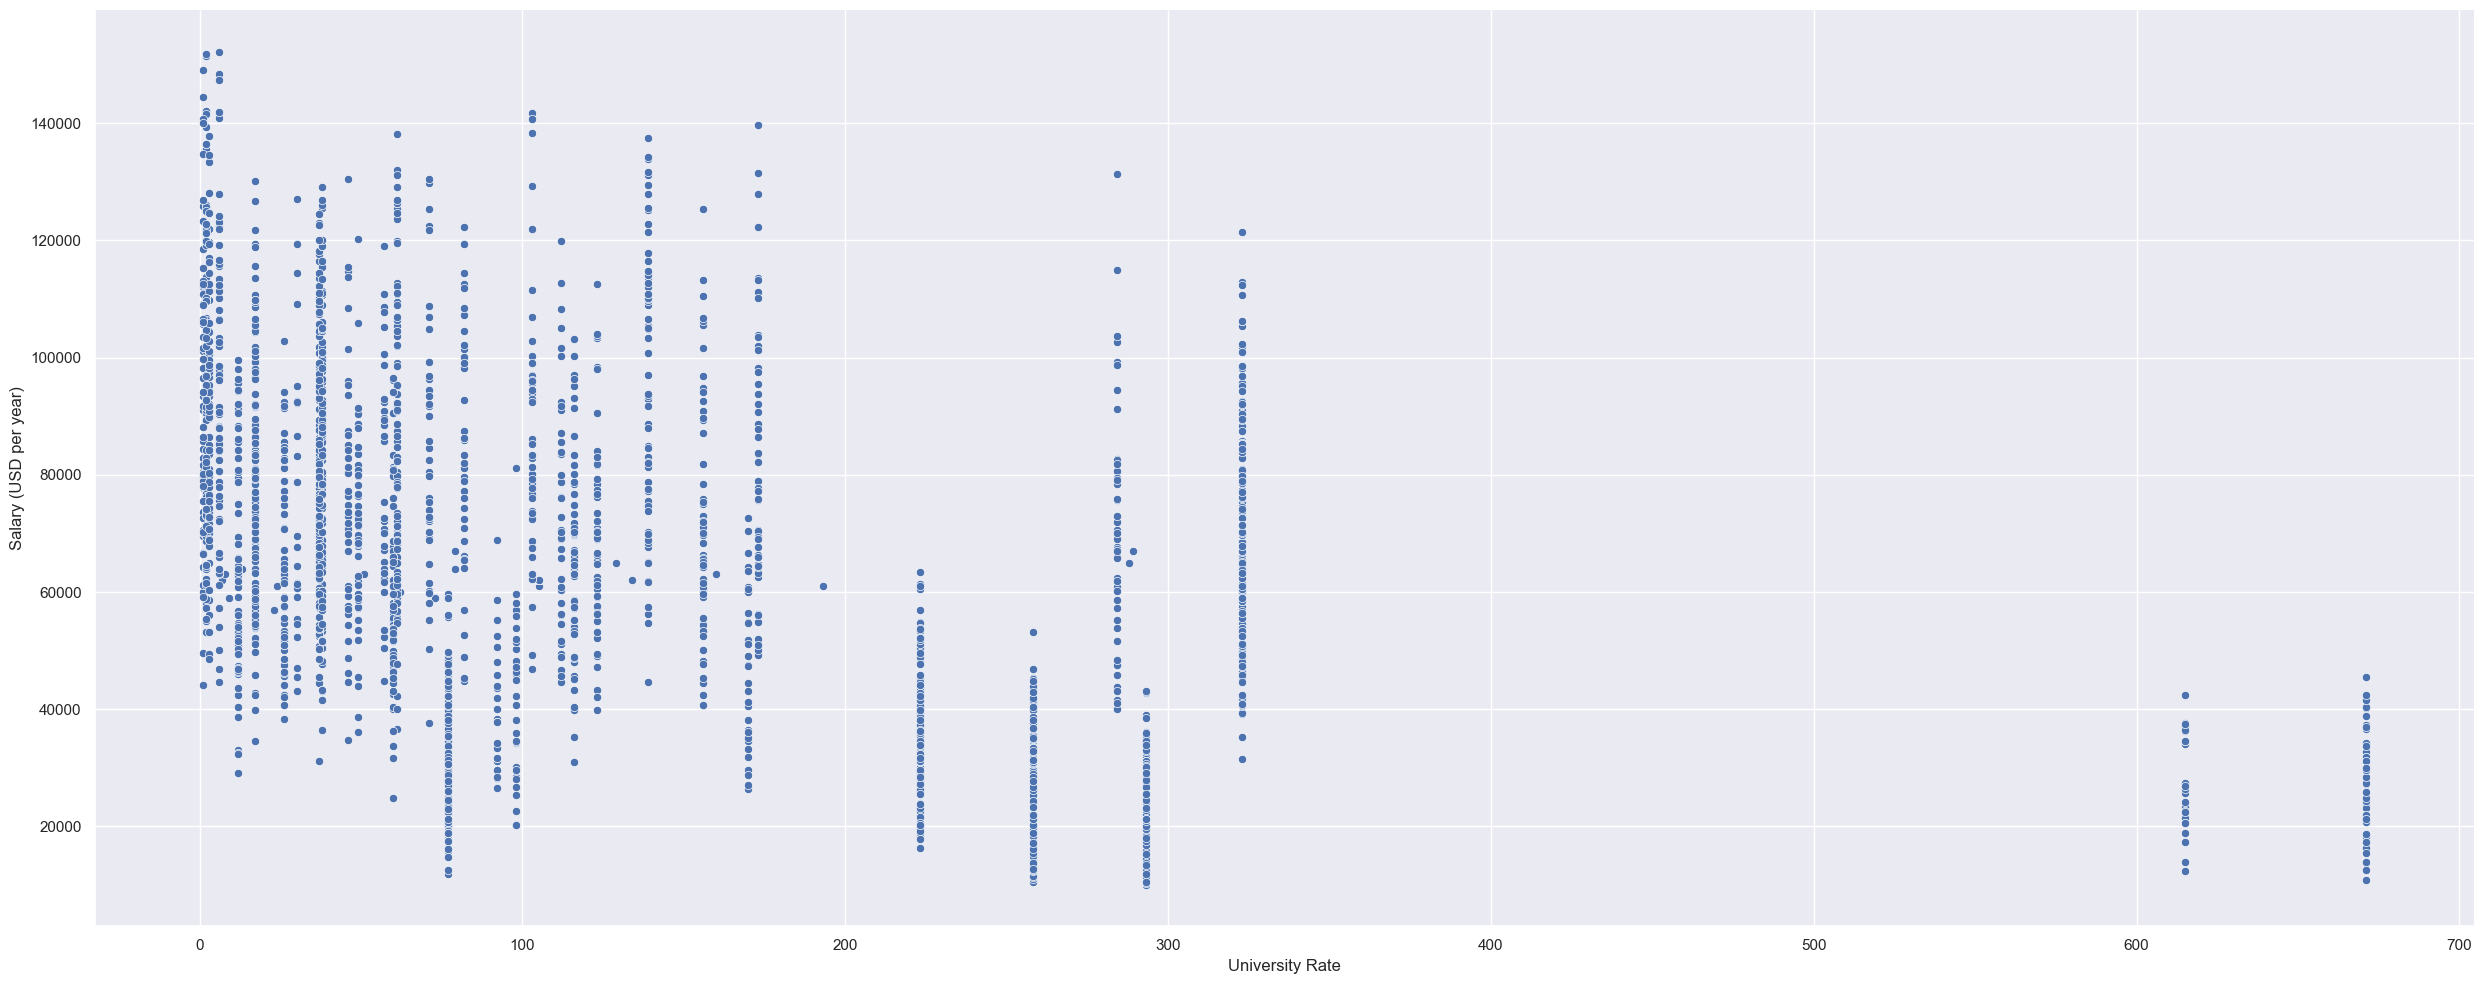

In [14]:
sns.set_theme(style="darkgrid")
sns.relplot(x = alumni_data["University Rate"], y = alumni_data["Salary (USD per year)"], height = 10, aspect = 2.5)

Text(0.5, 1.0, 'Salaries of students depend on the rank of their university (point - student)')

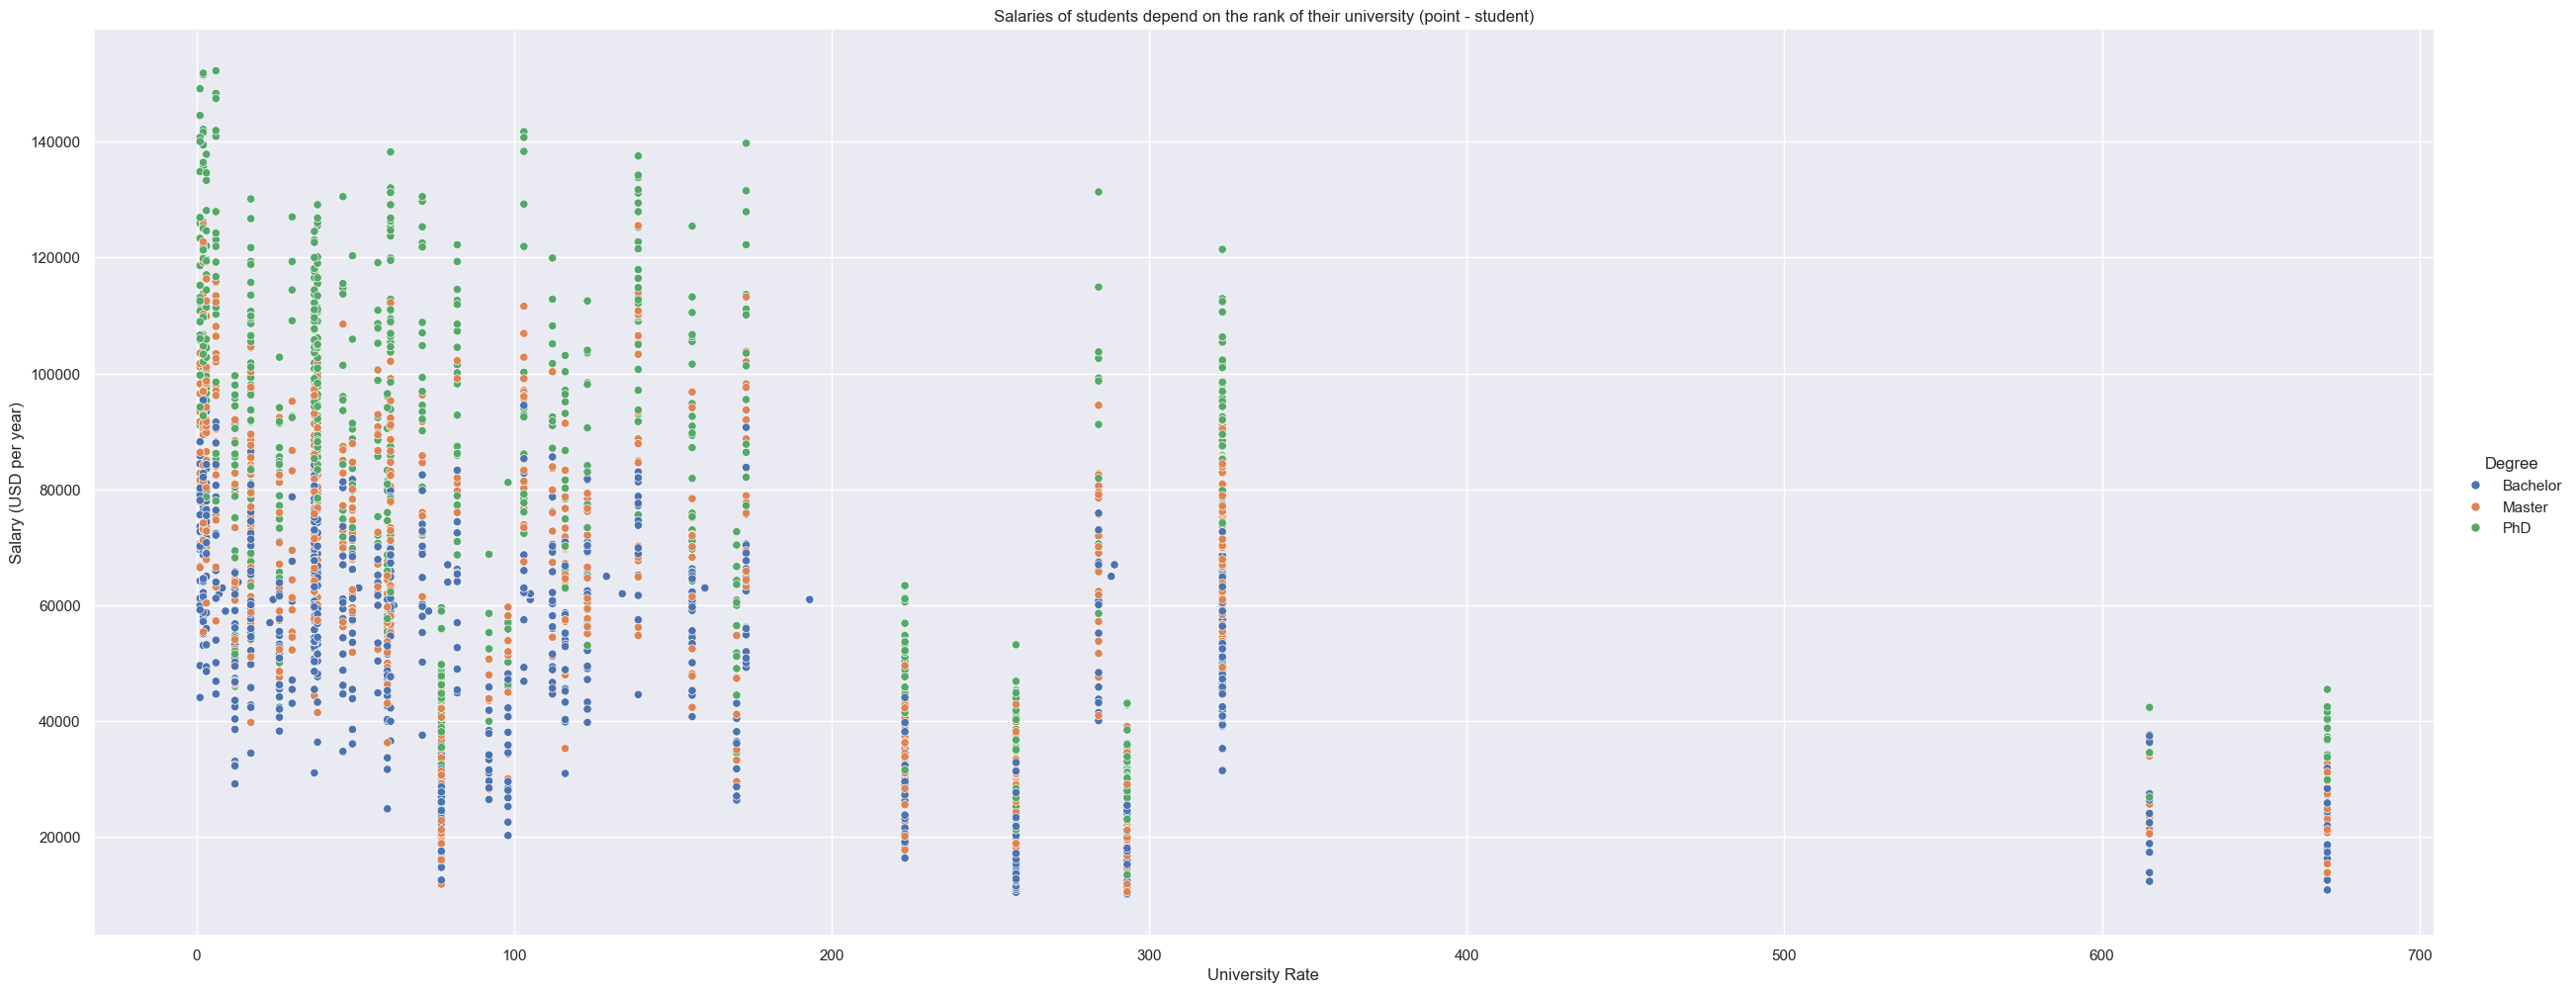

In [15]:
sns.set_theme(style="darkgrid")
sns.relplot(x = alumni_data["University Rate"], y = alumni_data["Salary (USD per year)"], hue = alumni_data["Degree"], height = 10, aspect = 2.5)
plt.title("Salaries of students depend on the rank of their university (point - student)")

In [16]:
uni_counts = alumni_data.University.value_counts()
valid_units = uni_counts[uni_counts >= 20].index
alumni_data = alumni_data[alumni_data.University.isin(valid_units)]

In [17]:
alumni_data = alumni_data.reset_index(drop=True)
alumni_data
#alumni_data - important dataframe, which describe degrees, salarries and field of students from top universities.
#our next step - find correlation between university_rate and alumni_data

,University,Degree,Field,Salary (USD per year),University Rate
0,Harvard University,Bachelor,IT,60000,1
1,Massachusetts Institute of Technology,Bachelor,Engineering,65000,3
2,Stanford University,Bachelor,Engineering,58000,2
3,University of Rochester,Bachelor,IT,61000,105
4,University of Connecticut,Bachelor,Engineering,61000,193
...,...,...,...,...,...
2925,Royal Institute of Technology,Bachelor,Engineering,64600,156
2926,Karolinska Institute,Bachelor,Business & Finance,55200,49
2927,Hebrew University of Jerusalem,PhD,Social Sciences,62300,61
2928,Kyoto University,Master,IT,52400,26


In [18]:
alumni_data["Salary (USD per year)"].describe()

count      2930.000000
mean      61638.327645
std       29334.873890
min       10100.000000
25%       36700.000000
50%       61200.000000
75%       81275.000000
max      152200.000000
Name: Salary (USD per year), dtype: float64

In [19]:
alumni_data.University.unique()

<StringArray>
[                      'Harvard University',
    'Massachusetts Institute of Technology',
                      'Stanford University',
                  'University of Rochester',
                'University of Connecticut',
                   'University of Delaware',
                   'University of Virginia',
    'Indian Institute of Technology Bombay',
                  'University of Cape Town',
                     'Karolinska Institute',
                  'University of Amsterdam',
                  'Imperial College London',
 'National Autonomous University of Mexico',
           'Hebrew University of Jerusalem',
            'Royal Institute of Technology',
                'Seoul National University',
         'National University of Singapore',
                  'University of São Paulo',
                    'University of Toronto',
           'Australian National University',
               'University of Buenos Aires',
                'King Abdulaziz Universit

In [20]:
mean_salary = alumni_data.groupby("University")["Salary (USD per year)"].mean()
mean_salary

University
Australian National University              83602.380952
Delft University of Technology              69324.000000
Fudan University                            47127.272727
Georgia Institute of Technology             95790.476190
Harvard University                          93052.307692
Hebrew University of Jerusalem              84912.631579
Heidelberg University                       76066.666667
Imperial College London                     76472.000000
Indian Institute of Technology Bombay       27331.034483
Indian Institute of Technology Delhi        26978.723404
Karolinska Institute                        70449.019608
King Abdulaziz University                   68621.081081
Kyoto University                            65039.285714
Massachusetts Institute of Technology       89295.890411
McGill University                           78905.147059
Nanyang Technological University            83616.000000
National Autonomous University of Mexico    27512.970711
National University 

In [21]:
mean_salary_uni_deg = alumni_data.groupby(["University", "Degree"])["Salary (USD per year)"].mean()
mean_salary_uni_field = alumni_data.groupby(["University", "Field"])["Salary (USD per year)"].mean()
mean_salary_uni_deg

University                      Degree  
Australian National University  Bachelor    64985.714286
                                Master      83633.333333
                                PhD         97305.263158
Delft University of Technology  Bachelor    55929.411765
                                Master      68047.619048
                                                ...     
University of Toronto           PhD         94095.652174
University of Virginia          Bachelor    64785.714286
École Polytechnique             Bachelor    53495.454545
                                Master      66128.571429
                                PhD         83780.000000
Name: Salary (USD per year), Length: 109, dtype: float64

In [22]:
mean_salary_uni_field

University                      Field                
Australian National University  Business & Finance       95475.000000
                                Engineering              85454.545455
                                Healthcare & Medicine    93600.000000
                                IT                       95755.555556
                                Natural Sciences         70833.333333
                                                             ...     
École Polytechnique             Engineering              63833.333333
                                Healthcare & Medicine    79166.666667
                                IT                       67015.000000
                                Natural Sciences         67350.000000
                                Social Sciences          50922.222222
Name: Salary (USD per year), Length: 218, dtype: float64

<Axes: >

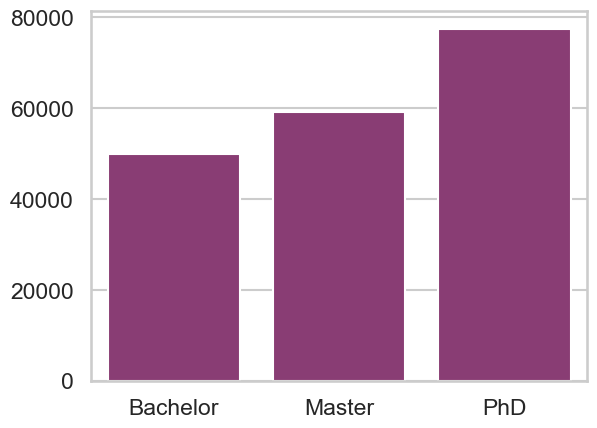

In [23]:
sns.set_theme(style="whitegrid", context="talk")
custom_palette = ["#95317A", "#3da386", "#5b98ed", "#d62728", "#9467bd"]
sns.set_palette(custom_palette)
sns.despine()
sns.barplot({"Bachelor" : alumni_data["Salary (USD per year)"][alumni_data.Degree == "Bachelor"].mean(),
             "Master" : alumni_data["Salary (USD per year)"][alumni_data.Degree == "Master"].mean(),
             "PhD" : alumni_data["Salary (USD per year)"][alumni_data.Degree == "PhD"].mean()})

In [24]:
temp_df = pd.DataFrame({
    'Salary': mean_salary_uni_deg,
    'Rank': mean_salary_uni_deg.index.get_level_values('University').map(rank_dict)
})
temp_df = temp_df.sort_values('Rank', ascending=False)
mean_salary_uni_deg = temp_df['Salary']

In [25]:
mean_salary_uni_deg

University                             Degree  
Indian Institute of Technology Delhi   Master       24581.250000
                                       Bachelor     20594.117647
                                       PhD          37471.428571
Indian Institute of Technology Bombay  PhD          34528.571429
                                       Master       25800.000000
                                                       ...      
Stanford University                    Master       88259.259259
                                       Bachelor     71396.428571
Harvard University                     PhD         111770.370370
                                       Bachelor     70547.368421
                                       Master       88957.894737
Name: Salary, Length: 109, dtype: float64

In [26]:
university_rate[university_rate["Institution"] == "Indian Institute of Technology Delhi"]

,World Rank,Institution,Location,National Rank,Quality of Education,Alumni Employment,Quality of Faculty,Research Output,Quality Publications,Influence,Citations,Score
670,671,Indian Institute of Technology Delhi,India,5,283,95,-,549,634,> 1000,> 1000,72.1


Text(0.5, 1.0, 'Mean salaries of bachelors graduated from top universities')

<Figure size 640x480 with 0 Axes>

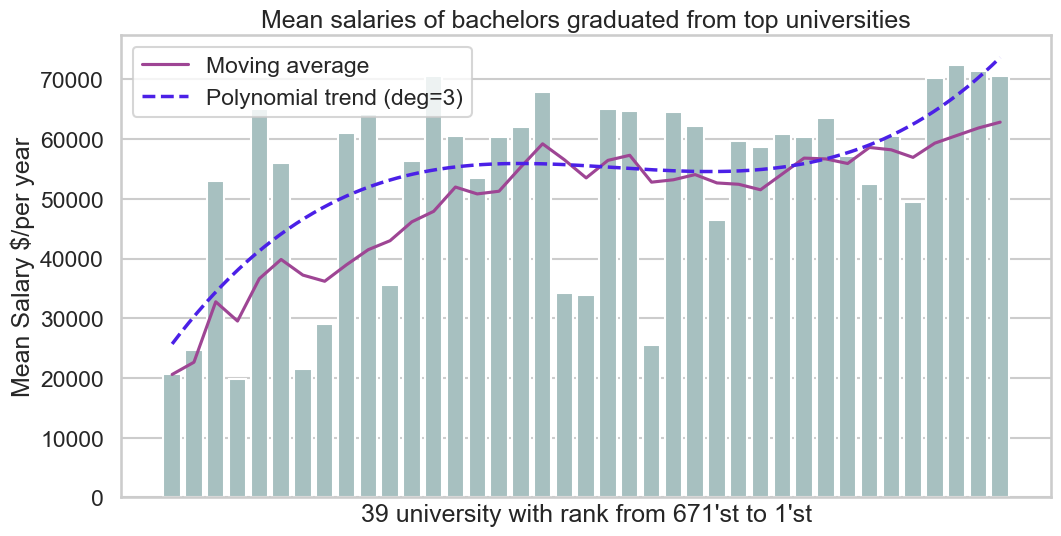

In [27]:
sns.set_theme(style="whitegrid", context="talk")
sns.despine()
plt.figure(figsize=(12, 6))
sns.barplot(mean_salary_uni_deg[mean_salary_uni_deg.index.get_level_values('Degree') == 'Bachelor'].values, color = "#A3C4C4")

moving_average = pd.Series(mean_salary_uni_deg[mean_salary_uni_deg.index.get_level_values('Degree') == 'Bachelor'].values).rolling(window=10, min_periods=1).mean().values
plt.plot(moving_average, color = "#9e4594", label = "Moving average")

x = np.arange(len(mean_salary_uni_deg[mean_salary_uni_deg.index.get_level_values('Degree') == 'Bachelor'].values))
degree = 3
coeffs = np.polyfit(x, mean_salary_uni_deg[mean_salary_uni_deg.index.get_level_values('Degree') == 'Bachelor'].values, degree)
poly = np.poly1d(coeffs)
x_smooth = np.linspace(x.min(), x.max(), 300)
y_smooth = poly(x_smooth)
plt.plot(x_smooth, y_smooth, '--', color="#4B20E7", linewidth=2.5, label=f"Polynomial trend (deg={degree})")

plt.xticks([]) 
plt.xlabel("39 university with rank from 671'st to 1'st")
plt.legend()
plt.ylabel("Mean Salary $/per year")
plt.title("Mean salaries of bachelors graduated from top universities")

Text(0.5, 1.0, 'Mean salaries of masters graduated from top universities')

<Figure size 640x480 with 0 Axes>

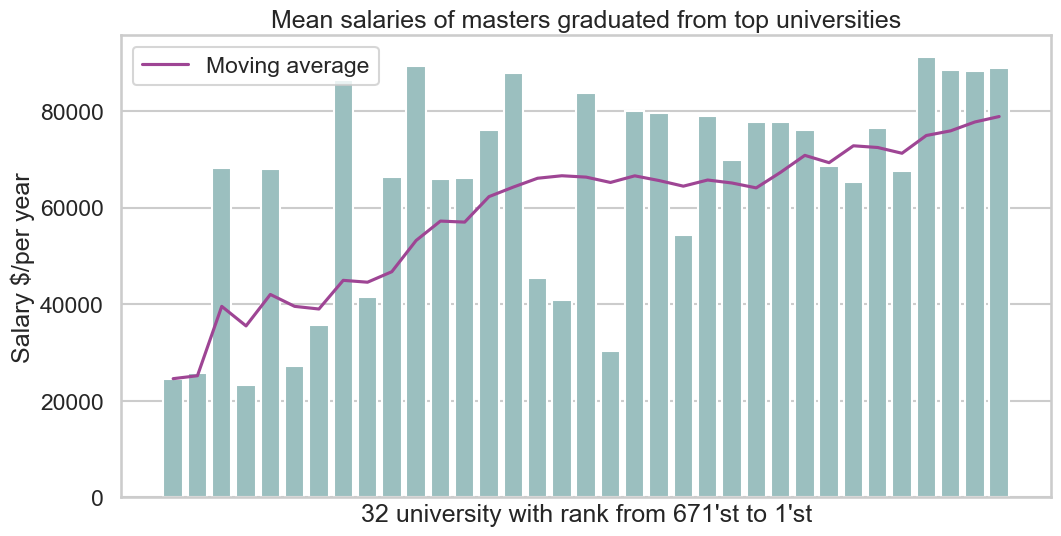

In [28]:
sns.set_theme(style="whitegrid", context="talk")
sns.despine()
plt.figure(figsize=(12, 6))
sns.barplot(mean_salary_uni_deg[mean_salary_uni_deg.index.get_level_values('Degree') == 'Master'].values, color = "#95C5C5")

moving_average = pd.Series(mean_salary_uni_deg[mean_salary_uni_deg.index.get_level_values('Degree') == 'Master'].values).rolling(window=10, min_periods=1).mean().values
plt.plot(moving_average, color = "#9e4594", label = "Moving average")
plt.xticks([]) 
plt.xlabel("32 university with rank from 671'st to 1'st")
plt.legend()
plt.ylabel("Salary $/per year")
plt.title("Mean salaries of masters graduated from top universities")

Text(0.5, 1.0, 'Mean salaries of masters graduated from top universities')

<Figure size 640x480 with 0 Axes>

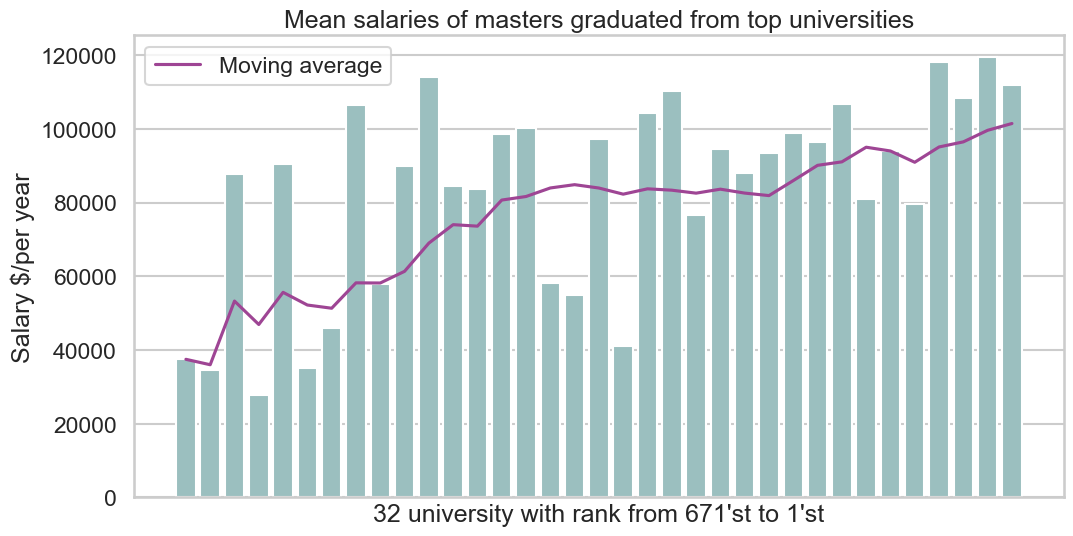

In [29]:
sns.set_theme(style="whitegrid", context="talk")
sns.despine()
plt.figure(figsize=(12, 6))
sns.barplot(mean_salary_uni_deg[mean_salary_uni_deg.index.get_level_values('Degree') == 'PhD'].values, color = "#95C5C5")

moving_average = pd.Series(mean_salary_uni_deg[mean_salary_uni_deg.index.get_level_values('Degree') == 'PhD'].values).rolling(window=10, min_periods=1).mean().values
plt.plot(moving_average, color = "#9e4594", label = "Moving average")
plt.xticks([]) 
plt.xlabel("32 university with rank from 671'st to 1'st")
plt.legend()
plt.ylabel("Salary $/per year")
plt.title("Mean salaries of masters graduated from top universities")

In [30]:
alumni_data

,University,Degree,Field,Salary (USD per year),University Rate
0,Harvard University,Bachelor,IT,60000,1
1,Massachusetts Institute of Technology,Bachelor,Engineering,65000,3
2,Stanford University,Bachelor,Engineering,58000,2
3,University of Rochester,Bachelor,IT,61000,105
4,University of Connecticut,Bachelor,Engineering,61000,193
...,...,...,...,...,...
2925,Royal Institute of Technology,Bachelor,Engineering,64600,156
2926,Karolinska Institute,Bachelor,Business & Finance,55200,49
2927,Hebrew University of Jerusalem,PhD,Social Sciences,62300,61
2928,Kyoto University,Master,IT,52400,26


In [31]:
alumni_data[(alumni_data["Field"] == "IT") & (alumni_data["Degree"] == "Bachelor")]["Salary (USD per year)"].mean()


np.float64(55502.89473684211)

In [32]:
set(alumni_data["Degree"])

{'Bachelor', 'Master', 'PhD'}

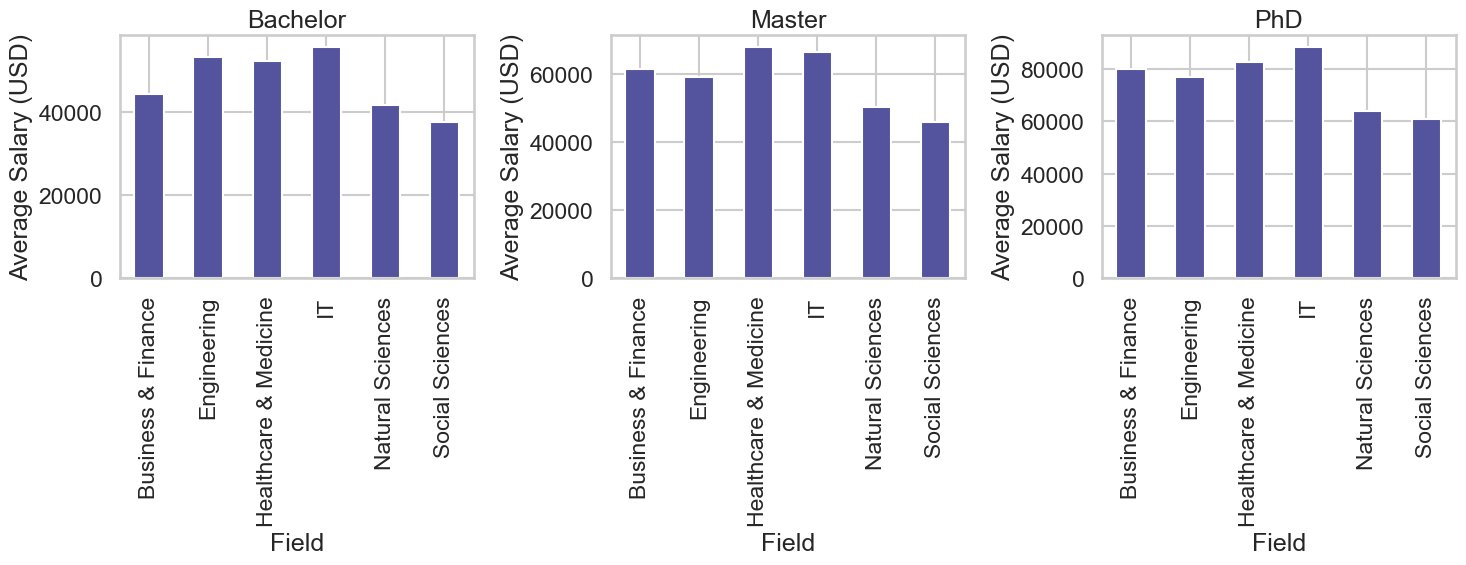

In [33]:
pivot = alumni_data.groupby(['Degree', 'Field'])['Salary (USD per year)'].mean().unstack(level=0)
fig, axes = plt.subplots(1, 3, figsize=(15,6))
for i, degree in enumerate(pivot.columns):
    pivot[degree].plot(kind='bar', ax=axes[i], color="#54549E")
    axes[i].set_title(degree)
    axes[i].set_xlabel('Field')
    axes[i].set_ylabel('Average Salary (USD)')
    axes[i].tick_params(axis='x')
plt.tight_layout()